# Figure 2 generation

These data correspond to preliminary tests ran using a weak UV as the CS because we thought it might be more salient to planaria. We were wary because UV itself causes contractions, so there was a risk of conflating sensitization with learning. But that's what control groups are for, so we tried it. The data here do NOT correspond to the runs done in the first week of April 2025. These are the preliminary ones that came before (20250328).

To add new data:
1) Ensure the data is in the CSV_FILEPATH and that it takes the expected format (see Google Sheet Misc_Paradigms_EXPORT)
2) In graphing code cell, add expected troupe to dictionary, where troupe is dictionary name and fill in colors, line style, etc.
3) Add troupe to graphing function call argument.

## Import packages, preprocess data

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set file path
CSV_FILEPATH = '../hand_scored_datasheets/Conditioning_Variants_HandScored_Sc1.csv'  # Update to your path

# Read the CSV
df = pd.read_csv(CSV_FILEPATH)

# Forward fill the Troupe column to fill empty cells
df['Troupe'] = df['Troupe'].replace('', np.nan)
df['Troupe'] = df['Troupe'].fillna(method='ffill')

# Forward fill the BlockNum column to fill empty cells (NEW!)
df['BlockNum'] = df['BlockNum'].replace('', np.nan)
df['BlockNum'] = df['BlockNum'].fillna(method='ffill')

# Convert W1-W6 columns to numeric, coercing errors to NaN
worm_columns = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6']
for col in worm_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert BlockNum to numeric (do this AFTER forward-filling)
df['BlockNum'] = pd.to_numeric(df['BlockNum'], errors='coerce')

print("Data loaded and preprocessed successfully!")
print(f"Total rows: {len(df)}")
print(f"Unique Troupe values: {df['Troupe'].unique()}")
print(f"Unique BlockNum values: {sorted(df['BlockNum'].dropna().unique())}")
print(f"BlockNum range: {df['BlockNum'].min()} to {df['BlockNum'].max()}")

Data loaded and preprocessed successfully!
Total rows: 900
Unique Troupe values: ['GD_test_1' 'bum_SM_test_1' 'SM_test_1' 'GD_1_UVSHOCK' 'GD_S_UVSHOCK'
 'GT_Charles_CSuvdimUCSshock' 'GD_B_WHITEUV' 'SM_WHITEUV' 'SM_PULSEUV'
 'SM_PULSEUV_oops,wrong_troupe']
Unique BlockNum values: [1.0, 2.0, 3.0, 4.0, 5.0]
BlockNum range: 1.0 to 5.0


## Define graphing code

In [55]:
import colorsys
import matplotlib.colors as mcolors

def _generate_worm_shades(base_color, n=6):
    """Generate n unique shades of base_color by varying lightness in HLS space."""
    rgb = mcolors.to_rgb(base_color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    light_lo, light_hi = 0.35, 0.80
    shades = []
    for i in range(n):
        t = i / max(n - 1, 1)
        new_l = light_lo + t * (light_hi - light_lo)
        r, g, b = colorsys.hls_to_rgb(h, new_l, s)
        shades.append((r, g, b))
    return shades


def create_graphs(data, groups=['GD_test_1', 'SM_test_1'], blocks=None, 
                  error_type='SEM', figsize=(10, 6),
                  title='Performance Across Blocks',
                  ylabel='Average Score',
                  y_values='probability',
                  ylim='auto', ylim_padding=0.1,
                  save=True, filename='block_performance.svg',
                  show_error_bars=True,
                  show_individual_worms=True):
    """
    Creates a line graph showing average performance across blocks for different groups.
    
    NOTE: This function handles variable trial counts automatically. It collects ALL trials 
    for each block and averages all W1-W6 values found.
    
    Parameters:
    -----------
    data : pandas DataFrame
        The preprocessed dataframe containing behavioral data
    groups : list of str
        List of troupe names to plot (e.g., ['GD_test_1', 'SM_test_1'])
        Default: ['GD_test_1', 'SM_test_1']
    blocks : list of int or None
        Specific blocks to include. If None, uses all available blocks
    error_type : str
        Type of error bars: 'SEM' or '95CI' (default: 'SEM')
    figsize : tuple
        Figure size (width, height) (default: (10, 6))
    title : str
        Plot title (default: 'Performance Across Blocks')
    ylabel : str
        Y-axis label (default: 'Average Score')
    y_values : str
        Type of y-axis values: 'probability' or 'counts' (default: 'probability')
        - 'probability': Average of all W1-W6 values (proportions)
        - 'counts': Sum each worm's scores, then average the 6 sums
    ylim : str, float, or tuple
        Y-axis limits. Options:
        - 'auto': Automatically determine based on data (default)
        - float: Sets max limit (min will be 0)
        - tuple (min, max): Explicitly set both limits
    ylim_padding : float
        Padding factor for auto y-limits (0.1 = 10% padding) (default: 0.1)
        Only used when ylim='auto'
    save : bool
        If True, saves the plot instead of displaying it (default: False)
    filename : str
        Filename for saving the plot (default: 'block_performance.png')
    show_error_bars : bool
        If True, displays error bars (default: True)
    show_individual_worms : bool
        If True, plots individual worm lines in unique shades of the group color (default: True)
    
    Returns:
    --------
    dict : Summary statistics for each group and block
    """
    
    # Validate error_type
    if error_type.upper() not in ['SEM', '95CI', 'CI']:
        raise ValueError("error_type must be 'SEM' or '95CI'")
    
    # Validate y_values
    if y_values.lower() not in ['probability', 'counts']:
        raise ValueError("y_values must be 'probability' or 'counts'")
    
    # Define styling for each group
    group_styles = {
        'GD_test_1': {
            'color': '#FF8C00',      # Orange (dark orange)
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'GD-1 test UV-Shock (n=6)'
        },
        'SM_test_1': {
            'color': '#2E7D32',       # Green (forest green)
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'SM test 1'
        },
        'GD_S_UVSHOCK': {
            'color': 'teal',          # #teal
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'GD-Spring water UV-Shock (n=6)'       
        },
        'GD_B_WHITEUV': {
            'color': '#002676',       # Berkeley blue
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'GD-Berkeley White-UV (n=2)'
        },
        'GD_1_UVSHOCK' : {
            'color': 'purple',        # Purple 
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'GD-1 Blue-UV (n=6)'
        },
        'SM_WHITEUV': {
            'color': '#A39F6D',       # Olive khaki thingy
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'SM White-UV (n=6)'},
        'SM_PULSEUV': {
            'color' : '#f05493',       # Dull pinkish color
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'SM Pusle-UV (n=5 or 6)'},
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store summary statistics
    summary_stats = {}
    
    # Store all plotted values for auto y-limit calculation
    all_means = []
    all_errors = []
    all_individual_vals = []
    
    # Track blocks with no data for debugging
    no_data_blocks = []
    
    # Process each group
    for group in groups:
        # Check if group has defined styling
        if group not in group_styles:
            print(f"Warning: No styling defined for group {group}, skipping...")
            continue
        
        style = group_styles[group]
        
        # Filter data for this group (exact match on Troupe column)
        group_data = data[data['Troupe'] == group].copy()
        
        if group_data.empty:
            print(f"Warning: No data found for group {group}")
            continue
        
        # Determine which blocks to process
        if blocks is None:
            available_blocks = sorted(group_data['BlockNum'].dropna().unique())
        else:
            available_blocks = sorted([b for b in blocks if b in group_data['BlockNum'].values])
        
        block_means = []
        block_errors = []
        valid_blocks = []
        worm_block_values = {col: [] for col in worm_columns}
        worm_valid_blocks = {col: [] for col in worm_columns}
        
        # Calculate statistics for each block
        for block_num in available_blocks:
            block_data = group_data[group_data['BlockNum'] == block_num]
            
            if block_data.empty:
                no_data_blocks.append(f"{group} Block {int(block_num)}")
                continue
            
            if y_values.lower() == 'probability':
                all_values = []
                for worm_col in worm_columns:
                    values = block_data[worm_col].dropna()
                    all_values.extend(values.tolist())
                    if len(values) > 0:
                        worm_val = values.mean()
                        worm_block_values[worm_col].append(worm_val)
                        worm_valid_blocks[worm_col].append(block_num)
                        all_individual_vals.append(worm_val)
                
                if not all_values:
                    no_data_blocks.append(f"{group} Block {int(block_num)}")
                    print(f"Warning: No valid data for {group}, Block {block_num}")
                    continue
                
                mean_val = np.mean(all_values)
                sem_val = np.std(all_values, ddof=1) / np.sqrt(len(all_values))
                
                if error_type.upper() == 'SEM':
                    error_val = sem_val
                    error_label = 'SEM'
                else:
                    n = len(all_values)
                    t_critical = stats.t.ppf(0.975, df=n-1)
                    error_val = t_critical * sem_val
                    error_label = '95% CI'
                
                n_datapoints = len(all_values)
                std_val = np.std(all_values, ddof=1)
                
            else:  # y_values == 'counts'
                worm_sums = []
                for worm_col in worm_columns:
                    values = block_data[worm_col].dropna()
                    if len(values) > 0:
                        worm_sum = values.sum()
                        worm_sums.append(worm_sum)
                        worm_block_values[worm_col].append(worm_sum)
                        worm_valid_blocks[worm_col].append(block_num)
                        all_individual_vals.append(worm_sum)
                
                if not worm_sums:
                    no_data_blocks.append(f"{group} Block {int(block_num)}")
                    print(f"Warning: No valid data for {group}, Block {block_num}")
                    continue
                
                mean_val = np.mean(worm_sums)
                sem_val = np.std(worm_sums, ddof=1) / np.sqrt(len(worm_sums))
                
                if error_type.upper() == 'SEM':
                    error_val = sem_val
                    error_label = 'SEM'
                else:
                    n = len(worm_sums)
                    t_critical = stats.t.ppf(0.975, df=n-1)
                    error_val = t_critical * sem_val
                    error_label = '95% CI'
                
                n_datapoints = len(worm_sums)
                std_val = np.std(worm_sums, ddof=1)
            
            block_means.append(mean_val)
            block_errors.append(error_val)
            valid_blocks.append(block_num)
            
            all_means.append(mean_val)
            all_errors.append(error_val)
            
            if group not in summary_stats:
                summary_stats[group] = {}
            
            summary_stats[group][f'Block_{int(block_num)}'] = {
                'mean': mean_val,
                'sem': sem_val,
                'error_value': error_val,
                'error_type': error_label,
                'n_datapoints': n_datapoints,
                'std': std_val,
                'calculation_method': y_values
            }
            
            print(f"{group} Block {int(block_num)}: Mean={mean_val:.3f}, {error_label}={error_val:.3f}, N={n_datapoints}")
        
        # Plot individual worm lines first (behind the mean)
        if show_individual_worms and valid_blocks:
            active_worms = [col for col in worm_columns if len(worm_block_values[col]) > 0]
            shades = _generate_worm_shades(style['color'], n=len(active_worms))
            for idx, worm_col in enumerate(active_worms):
                worm_label = f"{worm_col}" if idx == 0 else None
                ax.plot(worm_valid_blocks[worm_col], worm_block_values[worm_col],
                        linestyle='-', linewidth=1, color=shades[idx],
                        alpha=0.45, marker='.', markersize=4)
        
        # Plot the mean line for this group on top
        if valid_blocks:
            if show_error_bars:
                ax.errorbar(valid_blocks, block_means, yerr=block_errors,
                           marker=style['marker'], markersize=8, 
                           markerfacecolor=style['color'],
                           markeredgecolor=style['color'], markeredgewidth=1.5,
                           fillstyle=style['fillstyle'],
                           linestyle=style['linestyle'], linewidth=2.5, color=style['color'],
                           capsize=5, capthick=2, 
                           label=style['label'], alpha=0.9, zorder=5)
            else:
                ax.plot(valid_blocks, block_means,
                       marker=style['marker'], markersize=8, 
                       markerfacecolor=style['color'],
                       markeredgecolor=style['color'], markeredgewidth=1.5,
                       fillstyle=style['fillstyle'],
                       linestyle=style['linestyle'], linewidth=2.5, color=style['color'],
                       label=style['label'], alpha=0.9, zorder=5)
    
    # Set y-axis limits based on ylim parameter
    if ylim == 'auto':
        if all_means:
            max_val = max([m + e for m, e in zip(all_means, all_errors)])
            min_val = min([m - e for m, e in zip(all_means, all_errors)])
            if all_individual_vals:
                max_val = max(max_val, max(all_individual_vals))
                min_val = min(min_val, min(all_individual_vals))
            
            y_min = max(0, min_val - ylim_padding * (max_val - min_val))
            y_max = max_val + ylim_padding * (max_val - min_val)
            
            ax.set_ylim(y_min, y_max)
            print(f"\nAuto y-limits: [{y_min:.3f}, {y_max:.3f}]")
    elif isinstance(ylim, (int, float)):
        ax.set_ylim(0, ylim)
        print(f"\nY-limits set to: [0, {ylim}]")
    elif isinstance(ylim, (list, tuple)) and len(ylim) == 2:
        ax.set_ylim(ylim[0], ylim[1])
        print(f"\nY-limits set to: [{ylim[0]}, {ylim[1]}]")
    else:
        raise ValueError("ylim must be 'auto', a number, or a tuple (min, max)")
    
    # Formatting
    ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    
    if blocks is None:
        ax.set_xticks(range(1, 11))
    else:
        ax.set_xticks(blocks)
    
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    if no_data_blocks:
        print("\n" + "="*50)
        print("DEBUGGING: Blocks with no valid data (all NaNs):")
        for block_info in no_data_blocks:
            print(f"  - {block_info}")
        print("="*50)
    
    # Save or show
    if save:
        filepath = f"../figures/{filename}" if filename.endswith('.svg') else "../figures/{filename}.svg"
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to: {filepath}")
        #plt.close(fig)
        plt.show()
    else:
        plt.show()
    
    return summary_stats

print("Graphing function defined successfully!")

Graphing function defined successfully!


## Generate graphs, perform statistics

In [56]:
# ══════════════════════════════════════════════════════════════════════════════
#  PARADIGM-LEVEL COMBINED ANALYSIS
#  Depends on: df, worm_columns, _compute_bf10, _bf_label, _compute_tost
#  (all defined in the main code block above)
# ══════════════════════════════════════════════════════════════════════════════

# ── Define which troupes belong to each paradigm ─────────────────────────────
# Edit this dict if your groupings change
PARADIGM_GROUPS = {
    'UV-Shock': dict(
        troupes = ['GD_test_1', 'GD_1_UVSHOCK', 'GD_S_UVSHOCK'],
        blocks  = list(range(1, 6)),    # blocks 1–5
        color   = '#C0392B',            # dark red
        label   = 'UV-Shock  (pooled, max n=18)',
    ),
    'White-UV': dict(
        troupes = ['GD_B_WHITEUV', 'SM_WHITEUV'],
        blocks  = list(range(1, 4)),    # blocks 1–3
        color   = '#2471A3',            # steel blue
        label   = 'White-UV  (pooled, max n=12)',
        # ⚠ NOTE: GD_B_WHITEUV has blocks 1–3; SM_WHITEUV only has blocks 1–2.
        # At block 3 only GD_B_WHITEUV contributes (N drops from 12 to 6).
        # Common blocks = {1,2} only → Page's L cannot run (needs ≥ 3).
    ),
    'Pulse-UV': dict(
        troupes = ['SM_PULSEUV'],
        blocks  = list(range(1, 5)),    # blocks 1–4
        color   = '#8E44AD',            # purple
        label   = 'Pulse-UV  (max n=6)',
    ),
}


# ══════════════════════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS: Bayes Factor + TOST
# ══════════════════════════════════════════════════════════════════════════════

def _compute_bf10(sarr):
    """JZS Bayes Factor for a one-sample t-test (H1: mean != 0 vs H0: mean == 0).
    Uses the BayesFactor-style approximation with Cauchy prior (r = sqrt(2)/2)."""
    from scipy.special import gammaln
    from scipy.integrate import quad

    n = len(sarr)
    t_stat = np.mean(sarr) / (np.std(sarr, ddof=1) / np.sqrt(n))
    v = n - 1
    r = np.sqrt(2) / 2

    def integrand(g):
        return ((1 + n * g) ** (-0.5)
                * np.exp(-0.5 * t_stat**2 * v / ((1 + n * g) * (v + t_stat**2 / (1 + n * g)) if False else 1)  # placeholder
                ))

    # Simpler closed-form BF approximation (Rouder et al. 2009, Eq 1):
    def jzs_integrand(g):
        return ((1 + g) ** ((v - 1) / 2)
                * (1 + g * (1 - t_stat**2 / (v + t_stat**2))) ** (-(v + 1) / 2)
                * (2 * np.pi) ** (-0.5)
                * g ** (-1.5)
                * np.exp(-1 / (2 * g * r**2)))

    integral, _ = quad(jzs_integrand, 0, np.inf)
    bf10 = float(integral) if np.isfinite(integral) and integral > 0 else np.nan
    bf01 = 1.0 / bf10 if bf10 > 0 and np.isfinite(bf10) else np.nan
    return bf10, bf01


def _bf_label(bf01):
    """Interpret BF01 (evidence for null) using Jeffreys' scale."""
    if not np.isfinite(bf01):
        return "BF not computable"
    if bf01 >= 100:
        return "extreme evidence for H₀"
    if bf01 >= 30:
        return "very strong evidence for H₀"
    if bf01 >= 10:
        return "strong evidence for H₀"
    if bf01 >= 3:
        return "moderate evidence for H₀"
    if bf01 >= 1:
        return "anecdotal evidence for H₀"
    if bf01 >= 1/3:
        return "anecdotal evidence for H₁"
    if bf01 >= 1/10:
        return "moderate evidence for H₁"
    if bf01 >= 1/30:
        return "strong evidence for H₁"
    return "very strong evidence for H₁"


def _compute_tost(sarr, sesoi, alpha=0.05):
    """Two One-Sided Tests for equivalence of mean slope to zero."""
    n = len(sarr)
    mu = np.mean(sarr)
    se = np.std(sarr, ddof=1) / np.sqrt(n)
    df = n - 1

    t_lower = (mu - (-sesoi)) / se
    t_upper = (mu - sesoi) / se

    p_lower = 1 - stats.t.cdf(t_lower, df)
    p_upper = stats.t.cdf(t_upper, df)

    tost_p = max(p_lower, p_upper)

    return dict(
        t_lower=t_lower, p_lower=p_lower,
        t_upper=t_upper, p_upper=p_upper,
        tost_p=tost_p, sesoi=sesoi,
        equivalent=(tost_p < alpha),
    )


# ══════════════════════════════════════════════════════════════════════════════
#  COMBINED TREND ANALYSIS FUNCTION
# ══════════════════════════════════════════════════════════════════════════════
def analyze_combined_paradigm(data, paradigm_name, troupes, blocks,
                               y_values='counts', alpha=0.05, sesoi=1.0):
    """
    Pools all worms from multiple troupes within a paradigm and tests for
    an upward trend across blocks.

    Statistical design
    ──────────────────
    Each worm contributes exactly ONE slope (regressed within its own troupe's
    available blocks). Slopes are pooled across all troupes and tested with:
      ①  one-sample t-test  +  95 % CI on the mean slope
      ②  Bayesian t-test (JZS prior)  →  BF₀₁
      ③  TOST equivalence test  →  is the slope negligibly small?

    Limitation
    ──────────
    Worms from troupes with more blocks have slopes estimated from more data
    points (higher precision). This is a minor imbalance — noted in output.

    Parameters
    ----------
    data          : DataFrame   full preprocessed dataframe
    paradigm_name : str         name shown in printed output
    troupes       : list[str]   Troupe names to pool
    blocks        : list[int]   block numbers to include
    y_values      : str         'counts' or 'probability'
    sesoi         : float       smallest meaningful slope (contractions/block)
    """

    # ── Step 1: per-worm, per-block scores ───────────────────────────────────
    worm_data = {}   # {(troupe, worm_col): {block: score}}
    for troupe in troupes:
        gdata = data[data['Troupe'] == troupe].copy()
        if gdata.empty:
            continue
        troupe_blocks = sorted([b for b in blocks if b in gdata['BlockNum'].values])
        for wc in worm_columns:
            key = (troupe, wc)
            worm_data[key] = {}
            for blk in troupe_blocks:
                vals = gdata.loc[gdata['BlockNum'] == blk, wc].dropna()
                if len(vals):
                    worm_data[key][blk] = float(
                        vals.sum() if y_values == 'counts' else vals.mean()
                    )

    # ── Step 2: per-worm linear slopes ───────────────────────────────────────
    slopes, labels = [], []
    for (troupe, wc), blk_scores in worm_data.items():
        x = sorted(blk_scores.keys())
        y = [blk_scores[b] for b in x]
        if len(x) >= 2:
            slope, *_ = stats.linregress(x, y)
            slopes.append(slope)
            labels.append(f"{troupe}_{wc}")

    if len(slopes) < 2:
        return dict(paradigm=paradigm_name,
                    error='fewer than 2 worms had ≥ 2 data points')

    sarr    = np.array(slopes)
    n       = len(sarr)
    mu      = np.mean(sarr)
    se      = np.std(sarr, ddof=1) / np.sqrt(n)
    tc      = stats.t.ppf(0.975, df=n - 1)
    t_s, p2 = stats.ttest_1samp(sarr, 0)
    p1_up   = p2 / 2 if t_s > 0 else 1.0 - p2 / 2

    slope_res = dict(
        mean=mu, sem=se, ci95=(mu - tc * se, mu + tc * se),
        t=t_s, df=n - 1, p_two=p2, p_one_up=p1_up, n=n,
        per_worm=dict(zip(labels, slopes)),
        sig_up=(p1_up < alpha and mu > 0),
    )

    # ── Step 3: Bayes Factor ─────────────────────────────────────────────────
    try:
        bf10, bf01 = _compute_bf10(sarr)
        bf_res = dict(BF10=bf10, BF01=bf01, label=_bf_label(bf01))
    except Exception as e:
        bf_res = dict(error=str(e))

    # ── Step 4: TOST ─────────────────────────────────────────────────────────
    tost_res = _compute_tost(sarr, sesoi, alpha)

    return dict(
        paradigm=paradigm_name, troupes=troupes, blocks=blocks,
        n_worms=n, slope_test=slope_res, bf=bf_res,
        tost=tost_res,
    )


# ══════════════════════════════════════════════════════════════════════════════
#  PRINT RESULTS
# ══════════════════════════════════════════════════════════════════════════════
def print_paradigm_trend_results(trend_dict, plot_title='', sesoi=1.0):
    """Formatted console output of paradigm-level trend results."""
    W = 74
    hdr = (f"PARADIGM-LEVEL TREND ANALYSIS  ─  {plot_title}"
           if plot_title else "PARADIGM-LEVEL TREND ANALYSIS")
    print("\n" + "═" * W)
    print(f"  {hdr}")
    print(f"  Worms pooled across troupes within each paradigm")
    print(f"  H₁: upward trend (slope > 0)  |  α = 0.05  |  SESOI = ±{sesoi} cts/block")
    print("═" * W)

    for paradigm_name, res in trend_dict.items():
        if res is None or 'error' in res:
            msg = res['error'] if (res and 'error' in res) else 'no data'
            print(f"\n  {paradigm_name}: {msg}")
            continue

        print(f"\n{'─' * W}")
        print(f"  PARADIGM : {paradigm_name}")
        print(f"  Troupes  : {', '.join(res['troupes'])}")
        print(f"  Blocks   : {res['blocks']}")
        print(f"  N worms with ≥ 2 blocks of data : {res['n_worms']}")

        s  = res['slope_test']
        bf = res.get('bf', {})
        ts = res.get('tost', {})
        ci = s['ci95']

        # ① slope test
        print(f"\n  ① Per-worm slope t-test  (n = {s['n']} slopes pooled)")
        print(f"     Mean slope : {s['mean']:+.3f} ± {s['sem']:.3f} SEM")
        print(f"     95 % CI    : [{ci[0]:+.3f},  {ci[1]:+.3f}]")
        print(f"     t({s['df']}) = {s['t']:+.3f},  "
              f"p (two-sided) = {s['p_two']:.4f},  "
              f"p (one-sided ↑) = {s['p_one_up']:.4f}")
        # print individual slopes compactly
        per_worm_str = '  '.join(f"{k.split('_')[-1]}({k.rsplit('_',1)[0]})={v:+.2f}"
                                  for k, v in s['per_worm'].items())
        print(f"     Per worm : {per_worm_str}")
        if s['sig_up']:
            print("     ★  SIGNIFICANT UPWARD TREND ★")
        elif ci[0] < 0 < ci[1]:
            print("     ✗  Not significant — CI crosses zero (consistent with no trend)")
        else:
            print("     ✗  Not significant")

        # ② BF
        if 'BF01' in bf:
            print(f"\n  ② Bayesian t-test  (JZS prior, r = √2/2)")
            print(f"     BF₁₀ = {bf['BF10']:.3f}   BF₀₁ = {bf['BF01']:.3f}")
            print(f"     → {bf['label']}")
        elif 'error' in bf:
            print(f"\n  ② Bayes Factor: error — {bf['error']}")

        # ③ TOST
        if ts:
            print(f"\n  ③ TOST equivalence test  (SESOI = ±{ts['sesoi']} cts/block)")
            print(f"     t_lower = {ts['t_lower']:+.3f}   p_lower = {ts['p_lower']:.4f}   "
                  f"[H₀₁: slope ≤ −{ts['sesoi']}]")
            print(f"     t_upper = {ts['t_upper']:+.3f}   p_upper = {ts['p_upper']:.4f}   "
                  f"[H₀₂: slope ≥ +{ts['sesoi']}]")
            print(f"     TOST p = max(p_lower, p_upper) = {ts['tost_p']:.4f}  →  "
                  + ("✓ EQUIVALENT to no trend" if ts['equivalent']
                     else "✗ Inconclusive"))

        # verdict
        up_sig   = s['sig_up']
        bf01_val = bf.get('BF01')
        tost_eq  = ts.get('equivalent', False)

        print(f"\n  ▶  VERDICT for {paradigm_name}:")
        if up_sig:
            print("     Evidence FOR an upward trend.")
        elif bf01_val and bf01_val >= 10 and tost_eq:
            print("     Strong evidence AGAINST an upward trend (BF₀₁ ≥ 10 + TOST).")
        elif bf01_val and bf01_val >= 3 and tost_eq:
            print("     Moderate evidence AGAINST an upward trend (BF₀₁ ≥ 3 + TOST).")
        elif bf01_val and bf01_val >= 3:
            print("     BF favours no trend; TOST inconclusive (CI too wide).")
        elif tost_eq:
            print("     TOST confirms equivalence to no trend; BF inconclusive.")
        else:
            print("     INCONCLUSIVE — no trend detected but absence not confirmed.")
            print("     With small n, absence of significance ≠ evidence of absence.")

    print("\n" + "═" * W)
    print("  ⚠  Slopes are pooled across troupes within each paradigm.")
    print("     Worms from troupes with more blocks have slopes estimated")
    print("     from more data points (minor precision imbalance).")
    print("═" * W)


# ══════════════════════════════════════════════════════════════════════════════
#  COMBINED PARADIGM PLOT
# ══════════════════════════════════════════════════════════════════════════════
def _troupe_shades(base_color, n):
    """Generate n visually distinct shades from base_color for troupe lines."""
    import colorsys
    rgb = mcolors.to_rgb(base_color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    if n == 1:
        new_l = max(0.35, min(0.65, l))
        return [colorsys.hls_to_rgb(h, new_l, s)]
    shades = []
    for i in range(n):
        t = i / (n - 1)
        new_h = (h + 0.06 * (t - 0.5)) % 1.0
        new_l = 0.35 + t * 0.35
        r, g, b = colorsys.hls_to_rgb(new_h, new_l, max(0.4, s * 0.9))
        shades.append((r, g, b))
    return shades


def create_paradigm_graph(data, paradigm_groups_dict=None,
                          error_type='SEM', figsize=(10, 6),
                          title='Pooled paradigm-level analysis',
                          ylabel='Mean number of contractions',
                          y_values='counts',
                          ylim='auto', ylim_padding=0.1,
                          save=True, filename='../figures/Fig2A_Conditioning_Variants.svg',
                          show_error_bars=True,
                          show_individual_worms=True,
                          x_offset=0.10,
                          run_trend_test=True,
                          sesoi=1.0):
    """
    One mean +/- SEM line per paradigm, pooling ALL worms from ALL troupes
    at each block.  Optionally plots individual worm traces coloured by
    troupe (each troupe gets a unique shade of its paradigm colour).

    paradigm_groups_dict : dict or None
        Leave as None to use the module-level PARADIGM_GROUPS dict.
    """
    if paradigm_groups_dict is None:
        paradigm_groups_dict = PARADIGM_GROUPS

    fig, ax       = plt.subplots(figsize=figsize)
    summary_stats = {}
    all_means, all_errors = [], []
    all_individual_vals   = []
    no_data_blocks        = []

    pnames  = list(paradigm_groups_dict.keys())
    n_p     = len(pnames)
    offsets = np.linspace(-x_offset, x_offset, n_p) if n_p > 1 else [0.0]
    p_off   = dict(zip(pnames, offsets))

    for paradigm_name, pinfo in paradigm_groups_dict.items():
        troupes = pinfo['troupes']
        blocks  = pinfo['blocks']
        color   = pinfo['color']
        label   = pinfo['label']
        off     = p_off[paradigm_name]

        # ── Individual worm traces (plotted first so they sit behind mean) ───
        if show_individual_worms:
            troupe_colors = _troupe_shades(color, len(troupes))
            troupe_legend_added = set()
            for t_idx, troupe in enumerate(troupes):
                tc = troupe_colors[t_idx]
                gdata = data[data['Troupe'] == troupe].copy()
                if gdata.empty:
                    continue
                troupe_blocks = sorted(
                    [b for b in blocks if b in gdata['BlockNum'].values])
                for wc in worm_columns:
                    worm_x, worm_y = [], []
                    for blk in troupe_blocks:
                        vals = gdata.loc[gdata['BlockNum'] == blk, wc].dropna()
                        if len(vals):
                            score = float(
                                vals.sum() if y_values == 'counts'
                                else vals.mean())
                            worm_x.append(blk + off)
                            worm_y.append(score)
                            all_individual_vals.append(score)
                    if len(worm_x) >= 1:
                        lbl = troupe if troupe not in troupe_legend_added else None
                        ax.plot(worm_x, worm_y,
                                linestyle='-', linewidth=1.5, color=tc,
                                alpha=0.45, marker='.', markersize=4,
                                label=lbl, zorder=1)
                        if lbl:
                            troupe_legend_added.add(troupe)

        # ── Paradigm-level mean ± error ──────────────────────────────────────
        block_means, block_errors, valid_blocks = [], [], []

        for blk in blocks:
            pooled_scores = []
            for troupe in troupes:
                gdata = data[data['Troupe'] == troupe].copy()
                bdata = gdata[gdata['BlockNum'] == blk]
                if bdata.empty:
                    continue
                for wc in worm_columns:
                    vals = bdata[wc].dropna()
                    if len(vals):
                        score = float(
                            vals.sum() if y_values == 'counts' else vals.mean()
                        )
                        pooled_scores.append(score)

            if not pooled_scores:
                no_data_blocks.append(f"{paradigm_name} Block {blk}")
                continue

            n_dp     = len(pooled_scores)
            mean_val = np.mean(pooled_scores)
            sem_val  = np.std(pooled_scores, ddof=1) / np.sqrt(n_dp)

            if error_type.upper() == 'SEM':
                err_val, err_label = sem_val, 'SEM'
            else:
                t_crit             = stats.t.ppf(0.975, df=n_dp - 1)
                err_val, err_label = t_crit * sem_val, '95% CI'

            block_means.append(mean_val)
            block_errors.append(err_val)
            valid_blocks.append(blk)
            all_means.append(mean_val)
            all_errors.append(err_val)

            summary_stats.setdefault(paradigm_name, {})[f'Block_{int(blk)}'] = dict(
                mean=mean_val, sem=sem_val, error_value=err_val,
                error_type=err_label, n=n_dp,
            )
            print(f"{paradigm_name} Block {int(blk)}: "
                  f"Mean={mean_val:.3f}, {err_label}={err_val:.3f}, "
                  f"N={n_dp} worms")

        if valid_blocks:
            px = [x + off for x in valid_blocks]
            kw = dict(
                marker='o', markersize=8,
                markerfacecolor=color, markeredgecolor=color,
                markeredgewidth=1.5, fillstyle='full',
                linestyle='-', linewidth=2.5,
                color=color, label=label, alpha=0.95,
                zorder=5,
            )
            if show_error_bars:
                ax.errorbar(px, block_means, yerr=block_errors,
                            capsize=5, capthick=2, **kw)
            else:
                ax.plot(px, block_means, **kw)

    # y-axis
    if ylim == 'auto' and all_means:
        hi  = max(m + e for m, e in zip(all_means, all_errors))
        lo  = min(m - e for m, e in zip(all_means, all_errors))
        if all_individual_vals:
            hi = max(hi, max(all_individual_vals))
            lo = min(lo, min(all_individual_vals))
        pad = ylim_padding * (hi - lo)
        ax.set_ylim(max(0, lo - pad), hi + pad)
    elif isinstance(ylim, (int, float)):
        ax.set_ylim(0, ylim)
    elif isinstance(ylim, (list, tuple)) and len(ylim) == 2:
        ax.set_ylim(*ylim)
    elif ylim != 'auto':
        raise ValueError("ylim must be 'auto', a number, or (min, max)")

    ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel,         fontsize=12, fontweight='bold')
    ax.set_title(title,           fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)

    all_blks = sorted({b for pinfo in paradigm_groups_dict.values()
                       for b in pinfo['blocks']})
    ax.set_xticks(all_blks)
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()

    if no_data_blocks:
        print("\nBlocks with no valid data: " + ", ".join(no_data_blocks))

    if run_trend_test:
        trend_results = {
            pname: analyze_combined_paradigm(
                data, pname,
                pinfo['troupes'], pinfo['blocks'],
                y_values=y_values, sesoi=sesoi,
            )
            for pname, pinfo in paradigm_groups_dict.items()
        }
        print_paradigm_trend_results(trend_results, plot_title=title, sesoi=sesoi)
        summary_stats['_trend_analysis'] = trend_results

    if save:
        path = (f"{filename}"
                if filename.endswith('.svg')
                else f"{filename}.svg")
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved: {path}")
        plt.close(fig)
    else:
        plt.show()


    return summary_stats


print("Paradigm-level functions defined!")




Paradigm-level functions defined!


In [57]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN
# ══════════════════════════════════════════════════════════════════════════════
# Split into two dicts: one without Pulse-UV, one with only Pulse-UV
PARADIGM_GROUPS_MAIN = {k: v for k, v in PARADIGM_GROUPS.items() if k != 'Pulse-UV'}
PARADIGM_GROUPS_PULSE = {k: v for k, v in PARADIGM_GROUPS.items() if k == 'Pulse-UV'}

# Plot 1: UV-Shock + White-UV (original plot minus Pulse-UV)
paradigm_stats = create_paradigm_graph(
    df,
    paradigm_groups_dict = PARADIGM_GROUPS_MAIN,
    error_type  = 'SEM',
    y_values    = 'counts',
    ylim        = 9,
    title       = 'Pooled paradigm-level analysis',
    ylabel      = 'Mean number of contractions',
    x_offset    = 0.10,
    sesoi       = 1.0,
    run_trend_test = True,
    show_individual_worms = True,
    save        = True,
    filename    = '../figures/Fig2A_Conditioning_Variants.svg',
)


UV-Shock Block 1: Mean=0.944, SEM=0.328, N=18 worms
UV-Shock Block 2: Mean=1.167, SEM=0.500, N=18 worms
UV-Shock Block 3: Mean=1.056, SEM=0.439, N=18 worms
UV-Shock Block 4: Mean=1.056, SEM=0.408, N=18 worms
UV-Shock Block 5: Mean=0.667, SEM=0.323, N=18 worms
White-UV Block 1: Mean=1.500, SEM=0.544, N=12 worms
White-UV Block 2: Mean=0.500, SEM=0.195, N=12 worms
White-UV Block 3: Mean=0.167, SEM=0.167, N=6 worms

══════════════════════════════════════════════════════════════════════════
  PARADIGM-LEVEL TREND ANALYSIS  ─  Pooled paradigm-level analysis
  Worms pooled across troupes within each paradigm
  H₁: upward trend (slope > 0)  |  α = 0.05  |  SESOI = ±1.0 cts/block
══════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────────
  PARADIGM : UV-Shock
  Troupes  : GD_test_1, GD_1_UVSHOCK, GD_S_UVSHOCK
  Blocks   : [1, 2, 3, 4, 5]
  N worms with ≥ 2 blocks of data : 18

  ① Per-worm slope t-test  

In [58]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN — Fig2A split by species (GD = Girardia, SM = Schmidtea)
#  Produces two additional plots that show the Fig2A data separated by species.
#  - Fig2A_Conditioning_Variants_GD.svg : Girardia dorotocephala only
#  - Fig2A_Conditioning_Variants_SM.svg : Schmidtea mediterranea only
#  Colors match Fig2A (UV-Shock = dark red, White-UV = steel blue) so the
#  species-split panels are directly comparable to the pooled Fig2A figure.
# ══════════════════════════════════════════════════════════════════════════════

# ── Girardia dorotocephala (GD) only ────────────────────────────────────────
PARADIGM_GROUPS_GD = {
    'UV-Shock (GD)': dict(
        troupes = ['GD_test_1', 'GD_1_UVSHOCK', 'GD_S_UVSHOCK'],
        blocks  = list(range(1, 6)),    # blocks 1–5
        color   = '#C0392B',            # dark red (matches Fig2A)
        label   = 'UV-Shock — Girardia (pooled, max n=18)',
    ),
    'White-UV (GD)': dict(
        troupes = ['GD_B_WHITEUV'],
        blocks  = list(range(1, 4)),    # blocks 1–3
        color   = '#2471A3',            # steel blue (matches Fig2A)
        label   = 'White-UV — Girardia (n=2)',
    ),
}

# ── Schmidtea mediterranea (SM) only ────────────────────────────────────────
# NOTE: No SM troupe exists for UV-Shock in this dataset, so SM panel shows
# only the White-UV paradigm. SM_WHITEUV has data for blocks 1–2 only.
PARADIGM_GROUPS_SM = {
    'White-UV (SM)': dict(
        troupes = ['SM_WHITEUV'],
        blocks  = list(range(1, 3)),    # blocks 1–2 (SM_WHITEUV has no block 3)
        color   = '#2471A3',            # steel blue (matches Fig2A)
        label   = 'White-UV — Schmidtea (n=6)',
    ),
}

# ── Plot Fig2A_GD: Girardia only ────────────────────────────────────────────
print("\n" + "═" * 74)
print("  Fig2A — Girardia dorotocephala (GD) only")
print("═" * 74)
paradigm_stats_gd = create_paradigm_graph(
    df,
    paradigm_groups_dict = PARADIGM_GROUPS_GD,
    error_type  = 'SEM',
    y_values    = 'counts',
    ylim        = 9,                    # match Fig2A for direct comparison
    title       = 'Pooled paradigm-level analysis — Girardia (GD)',
    ylabel      = 'Mean number of contractions',
    x_offset    = 0.10,
    sesoi       = 1.0,
    run_trend_test = True,
    show_individual_worms = True,
    save        = True,
    filename    = '../figures/Fig2A_Conditioning_Variants_GD.svg',
)

# ── Plot Fig2A_SM: Schmidtea only ───────────────────────────────────────────
print("\n" + "═" * 74)
print("  Fig2A — Schmidtea mediterranea (SM) only")
print("═" * 74)
paradigm_stats_sm = create_paradigm_graph(
    df,
    paradigm_groups_dict = PARADIGM_GROUPS_SM,
    error_type  = 'SEM',
    y_values    = 'counts',
    ylim        = 9,                    # match Fig2A for direct comparison
    title       = 'Pooled paradigm-level analysis — Schmidtea (SM)',
    ylabel      = 'Mean number of contractions',
    x_offset    = 0.0,                  # single paradigm, no horizontal jitter
    sesoi       = 1.0,
    run_trend_test = True,
    show_individual_worms = True,
    save        = True,
    filename    = '../figures/Fig2A_Conditioning_Variants_SM.svg',
)



══════════════════════════════════════════════════════════════════════════
  Fig2A — Girardia dorotocephala (GD) only
══════════════════════════════════════════════════════════════════════════
UV-Shock (GD) Block 1: Mean=0.944, SEM=0.328, N=18 worms
UV-Shock (GD) Block 2: Mean=1.167, SEM=0.500, N=18 worms
UV-Shock (GD) Block 3: Mean=1.056, SEM=0.439, N=18 worms
UV-Shock (GD) Block 4: Mean=1.056, SEM=0.408, N=18 worms
UV-Shock (GD) Block 5: Mean=0.667, SEM=0.323, N=18 worms
White-UV (GD) Block 1: Mean=1.500, SEM=1.025, N=6 worms
White-UV (GD) Block 2: Mean=0.167, SEM=0.167, N=6 worms
White-UV (GD) Block 3: Mean=0.167, SEM=0.167, N=6 worms

══════════════════════════════════════════════════════════════════════════
  PARADIGM-LEVEL TREND ANALYSIS  ─  Pooled paradigm-level analysis — Girardia (GD)
  Worms pooled across troupes within each paradigm
  H₁: upward trend (slope > 0)  |  α = 0.05  |  SESOI = ±1.0 cts/block
════════════════════════════════════════════════════════════════════════

UV-Shock protocol — GD (pooled across 3 troupes):
  Block 1: mean=0.944, SEM=0.328, N=18 worms
  Block 2: mean=1.167, SEM=0.500, N=18 worms
  Block 3: mean=1.056, SEM=0.439, N=18 worms
  Block 4: mean=1.056, SEM=0.408, N=18 worms
  Block 5: mean=0.667, SEM=0.323, N=18 worms

White-UV protocol — GD (GD_B_WHITEUV):
  Block 1: mean=1.500, SEM=1.025, N=6 worms
  Block 2: mean=0.167, SEM=0.167, N=6 worms
  Block 3: mean=0.167, SEM=0.167, N=6 worms

White-UV protocol — SM (SM_WHITEUV):
  Block 1: mean=1.500, SEM=0.500, N=6 worms
  Block 2: mean=0.833, SEM=0.307, N=6 worms

══════════════════════════════════════════════════════════════════════════
  PARADIGM-LEVEL TREND ANALYSIS  ─  Protocol × Species split
  Worms pooled across troupes within each paradigm
  H₁: upward trend (slope > 0)  |  α = 0.05  |  SESOI = ±1.0 cts/block
══════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────────
  PARADIGM : GD U

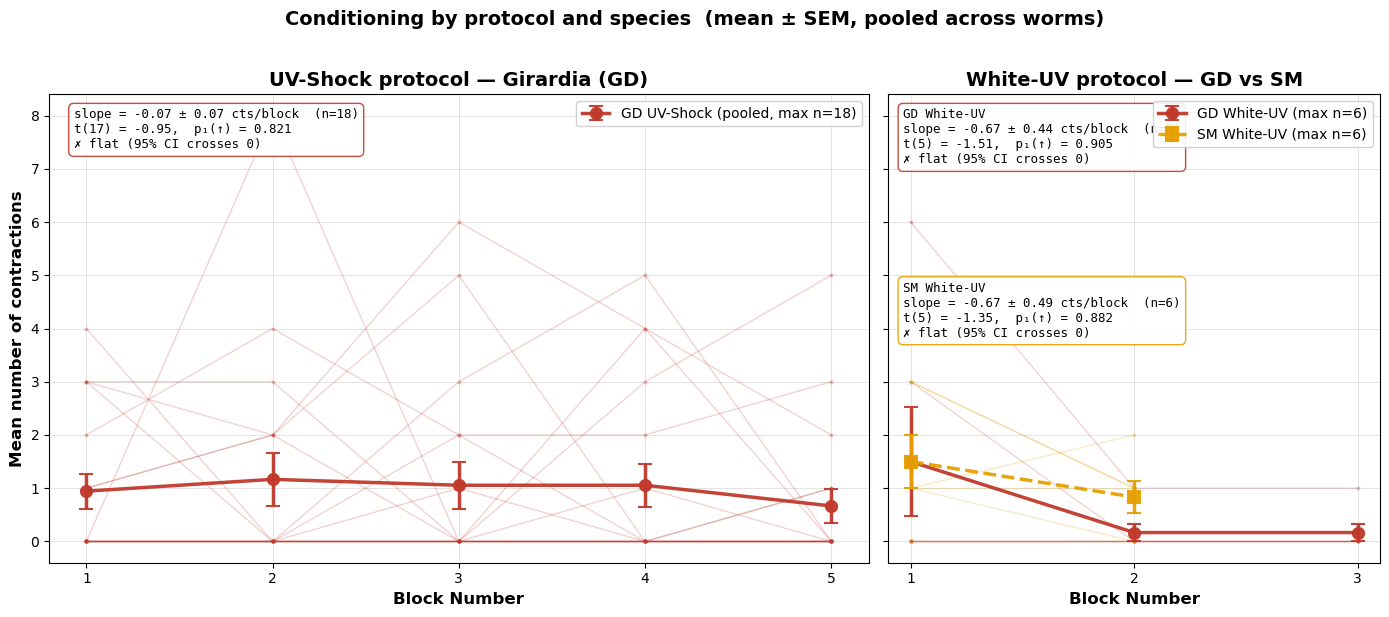

In [59]:
# ══════════════════════════════════════════════════════════════════════════════
#  Two-subplot summary: protocol × species split
#  Left subplot — UV-Shock protocol (GD only, no SM UV-Shock data exists):
#    • Mean ± SEM pooled across GD_test_1, GD_1_UVSHOCK, GD_S_UVSHOCK
#  Right subplot — White-UV protocol, both species side-by-side:
#    • GD line — GD_B_WHITEUV
#    • SM line — SM_WHITEUV
#  Mean ± SEM contractions per worm per block (counts; matches Fig2A).
# ══════════════════════════════════════════════════════════════════════════════

def _pool_per_worm_counts(data, troupes, block):
    """Return list of per-worm contraction sums for `block`, pooled across `troupes`.
    Each entry is one worm's total contractions in that block (across all trials)."""
    scores = []
    for t in troupes:
        bd = data[(data['Troupe'] == t) & (data['BlockNum'] == block)]
        if bd.empty:
            continue
        for wc in worm_columns:
            vals = bd[wc].dropna()
            if len(vals):
                scores.append(float(vals.sum()))
    return scores


def _block_mean_sem(data, troupes, blocks):
    """Per-block mean, SEM, and N across worms pooled from `troupes`."""
    xs, means, sems, ns = [], [], [], []
    for b in blocks:
        s = _pool_per_worm_counts(data, troupes, b)
        if not s:
            continue
        arr = np.array(s)
        xs.append(b)
        means.append(arr.mean())
        sems.append(arr.std(ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0)
        ns.append(len(arr))
    return np.array(xs), np.array(means), np.array(sems), ns


def _per_worm_traces(data, troupes, blocks):
    """One trajectory per individual worm = (troupe, worm_column).
    Returns list of (xs, ys) tuples where xs are blocks and ys are
    per-block contraction sums for that worm."""
    traces = []
    for t in troupes:
        for wc in worm_columns:
            xs, ys = [], []
            for b in blocks:
                bd = data[(data['Troupe'] == t) & (data['BlockNum'] == b)]
                if bd.empty:
                    continue
                vals = bd[wc].dropna()
                if len(vals):
                    xs.append(b)
                    ys.append(float(vals.sum()))
            if xs:
                traces.append((xs, ys))
    return traces


# ── Group definitions ───────────────────────────────────────────────────────
GD_UVSHOCK_TROUPES = ['GD_test_1', 'GD_1_UVSHOCK', 'GD_S_UVSHOCK']
GD_WHITEUV_TROUPES = ['GD_B_WHITEUV']
SM_WHITEUV_TROUPES = ['SM_WHITEUV']

GD_UVSHOCK_BLOCKS  = list(range(1, 6))   # blocks 1–5
GD_WHITEUV_BLOCKS  = list(range(1, 4))   # blocks 1–3
SM_WHITEUV_BLOCKS  = list(range(1, 3))   # blocks 1–2

# Colors  (right panel is species-coded: red = GD, yellow-orange = SM)
COLOR_UVSHOCK    = '#C0392B'   # dark red — matches Fig2A UV-Shock
COLOR_WHITEUV_GD = '#C0392B'   # dark red — same as UV-Shock, so GD is red in both panels
COLOR_WHITEUV_SM = '#E69F00'   # Wong yellow-orange (colorblind-safe, distinct from red)

# ── Compute per-block stats ─────────────────────────────────────────────────
x_gd_uv, m_gd_uv, s_gd_uv, n_gd_uv = _block_mean_sem(df, GD_UVSHOCK_TROUPES, GD_UVSHOCK_BLOCKS)
x_gd_wu, m_gd_wu, s_gd_wu, n_gd_wu = _block_mean_sem(df, GD_WHITEUV_TROUPES, GD_WHITEUV_BLOCKS)
x_sm_wu, m_sm_wu, s_sm_wu, n_sm_wu = _block_mean_sem(df, SM_WHITEUV_TROUPES, SM_WHITEUV_BLOCKS)

print(f"UV-Shock protocol — GD (pooled across {len(GD_UVSHOCK_TROUPES)} troupes):")
for b, m, s, n in zip(x_gd_uv, m_gd_uv, s_gd_uv, n_gd_uv):
    print(f"  Block {int(b)}: mean={m:.3f}, SEM={s:.3f}, N={n} worms")

print(f"\nWhite-UV protocol — GD (GD_B_WHITEUV):")
for b, m, s, n in zip(x_gd_wu, m_gd_wu, s_gd_wu, n_gd_wu):
    print(f"  Block {int(b)}: mean={m:.3f}, SEM={s:.3f}, N={n} worms")

print(f"\nWhite-UV protocol — SM (SM_WHITEUV):")
for b, m, s, n in zip(x_sm_wu, m_sm_wu, s_sm_wu, n_sm_wu):
    print(f"  Block {int(b)}: mean={m:.3f}, SEM={s:.3f}, N={n} worms")

# ── Per-population trend tests (H1: slope > 0) ───────────────────────────────
# Reuses analyze_combined_paradigm + print_paradigm_trend_results defined
# in cell 6 (per-worm regression slopes + t-test, JZS BF, TOST equivalence).
trend_gd_uv = analyze_combined_paradigm(
    df, 'GD UV-Shock', GD_UVSHOCK_TROUPES, GD_UVSHOCK_BLOCKS,
    y_values='counts', sesoi=1.0,
)
trend_gd_wu = analyze_combined_paradigm(
    df, 'GD White-UV', GD_WHITEUV_TROUPES, GD_WHITEUV_BLOCKS,
    y_values='counts', sesoi=1.0,
)
trend_sm_wu = analyze_combined_paradigm(
    df, 'SM White-UV', SM_WHITEUV_TROUPES, SM_WHITEUV_BLOCKS,
    y_values='counts', sesoi=1.0,
)

print_paradigm_trend_results(
    {'GD UV-Shock': trend_gd_uv,
     'GD White-UV': trend_gd_wu,
     'SM White-UV': trend_sm_wu},
    plot_title='Protocol × Species split',
    sesoi=1.0,
)


def _trend_annotation_text(res, label_prefix=''):
    """Compact 3-line annotation summarising slope + one-sided test + verdict."""
    if 'error' in res:
        return f"{label_prefix}{res['error']}"
    s = res['slope_test']
    if s['sig_up']:
        verdict = '★ significant upward trend'
    elif s['ci95'][0] < 0 < s['ci95'][1]:
        verdict = '✗ flat (95% CI crosses 0)'
    else:
        verdict = '✗ not significant'
    pre = f"{label_prefix}" if label_prefix else ''
    return (f"{pre}slope = {s['mean']:+.2f} ± {s['sem']:.2f} cts/block  (n={s['n']})\n"
            f"{' '*len(pre)}t({s['df']}) = {s['t']:+.2f},  p₁(↑) = {s['p_one_up']:.3f}\n"
            f"{' '*len(pre)}{verdict}")


# ── Plot ────────────────────────────────────────────────────────────────────
fig, (ax_uv, ax_wu) = plt.subplots(
    1, 2, figsize=(14, 6),
    sharey=True,
    gridspec_kw={'width_ratios': [5, 3]},  # x-axis ranges: UV-Shock 5 blocks, White-UV 3 blocks
)

# Left: UV-Shock protocol, GD only
# Individual worm traces (low opacity, behind mean)
for xs, ys in _per_worm_traces(df, GD_UVSHOCK_TROUPES, GD_UVSHOCK_BLOCKS):
    ax_uv.plot(xs, ys, color=COLOR_UVSHOCK, alpha=0.22, linewidth=1,
               marker='.', markersize=4, zorder=1)

ax_uv.errorbar(x_gd_uv, m_gd_uv, yerr=s_gd_uv,
               color=COLOR_UVSHOCK, linestyle='-', linewidth=2.5,
               marker='o', markersize=8,
               markerfacecolor=COLOR_UVSHOCK, markeredgecolor=COLOR_UVSHOCK,
               markeredgewidth=1.5, capsize=5, capthick=2, alpha=0.95,
               label=f"GD UV-Shock (pooled, max n={max(n_gd_uv)})", zorder=5)

ax_uv.set_title('UV-Shock protocol — Girardia (GD)', fontsize=14, fontweight='bold')
ax_uv.set_xlabel('Block Number', fontsize=12, fontweight='bold')
ax_uv.set_ylabel('Mean number of contractions', fontsize=12, fontweight='bold')
ax_uv.set_xticks(GD_UVSHOCK_BLOCKS)
ax_uv.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax_uv.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax_uv.set_axisbelow(True)

# Trend-test annotation
ax_uv.text(0.03, 0.97, _trend_annotation_text(trend_gd_uv),
           transform=ax_uv.transAxes, fontsize=9, va='top', ha='left',
           family='monospace',
           bbox=dict(boxstyle='round,pad=0.4',
                     facecolor='white', edgecolor=COLOR_UVSHOCK, alpha=0.9))

# Right: White-UV protocol, GD vs SM
# Individual worm traces (low opacity, behind means)
for xs, ys in _per_worm_traces(df, GD_WHITEUV_TROUPES, GD_WHITEUV_BLOCKS):
    ax_wu.plot(xs, ys, color=COLOR_WHITEUV_GD, alpha=0.22, linewidth=1,
               marker='.', markersize=4, zorder=1)
for xs, ys in _per_worm_traces(df, SM_WHITEUV_TROUPES, SM_WHITEUV_BLOCKS):
    ax_wu.plot(xs, ys, color=COLOR_WHITEUV_SM, alpha=0.22, linewidth=1,
               marker='.', markersize=4, zorder=1)

ax_wu.errorbar(x_gd_wu, m_gd_wu, yerr=s_gd_wu,
               color=COLOR_WHITEUV_GD, linestyle='-', linewidth=2.5,
               marker='o', markersize=8,
               markerfacecolor=COLOR_WHITEUV_GD, markeredgecolor=COLOR_WHITEUV_GD,
               markeredgewidth=1.5, capsize=5, capthick=2, alpha=0.95,
               label=f"GD White-UV (max n={max(n_gd_wu)})", zorder=5)
ax_wu.errorbar(x_sm_wu, m_sm_wu, yerr=s_sm_wu,
               color=COLOR_WHITEUV_SM, linestyle='--', linewidth=2.5,
               marker='s', markersize=8,
               markerfacecolor=COLOR_WHITEUV_SM, markeredgecolor=COLOR_WHITEUV_SM,
               markeredgewidth=1.5, capsize=5, capthick=2, alpha=0.95,
               label=f"SM White-UV (max n={max(n_sm_wu)})", zorder=5)

ax_wu.set_title('White-UV protocol — GD vs SM', fontsize=14, fontweight='bold')
ax_wu.set_xlabel('Block Number', fontsize=12, fontweight='bold')
all_wu_blocks = sorted(set(GD_WHITEUV_BLOCKS) | set(SM_WHITEUV_BLOCKS))
ax_wu.set_xticks(all_wu_blocks)
ax_wu.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax_wu.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax_wu.set_axisbelow(True)

# Trend-test annotations (stacked: GD on top, SM below)
ax_wu.text(0.03, 0.97, "GD White-UV\n" + _trend_annotation_text(trend_gd_wu),
           transform=ax_wu.transAxes, fontsize=9, va='top', ha='left',
           family='monospace',
           bbox=dict(boxstyle='round,pad=0.4',
                     facecolor='white', edgecolor=COLOR_WHITEUV_GD, alpha=0.9))
ax_wu.text(0.03, 0.60, "SM White-UV\n" + _trend_annotation_text(trend_sm_wu),
           transform=ax_wu.transAxes, fontsize=9, va='top', ha='left',
           family='monospace',
           bbox=dict(boxstyle='round,pad=0.4',
                     facecolor='white', edgecolor=COLOR_WHITEUV_SM, alpha=0.9))

fig.suptitle('Conditioning by protocol and species  (mean ± SEM, pooled across worms)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

savepath = '../figures/Fig2A_Protocol_SpeciesSplit.svg'
fig.savefig(savepath, dpi=300, bbox_inches='tight')
print(f"\nSaved: {savepath}")
plt.show()


══════════════════════════════════════════════════════════════════════════════
  Jacobson (1966) CC reference slope  (N=5 published block means)
    slope = +1.400 responses/block
    SE    = 0.402
    t(3) = +3.483,  p = 0.0400
══════════════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════════════
  COMPARISON TO JACOBSON CC  (reference slope = +1.400 resp/block)
══════════════════════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────────────────
  GD UV-Shock   (n = 18 worms)
    Mean slope : -0.067 ± 0.070 SEM   95% CI [-0.215, +0.082]
    Jacobson   : +1.400 ± 0.402 SE (N=5 block means)
    Difference : -1.467
    ① One-sample t  (Jacobson as fixed reference)
         t(17) = -20.810,  p(two-sided) = 0.0000,  p(slope < Jac) = 0.0000
         Cohen's d = -4.905
         95% CI excludes Jacobson? True
    ② Welch's t   (accounts f

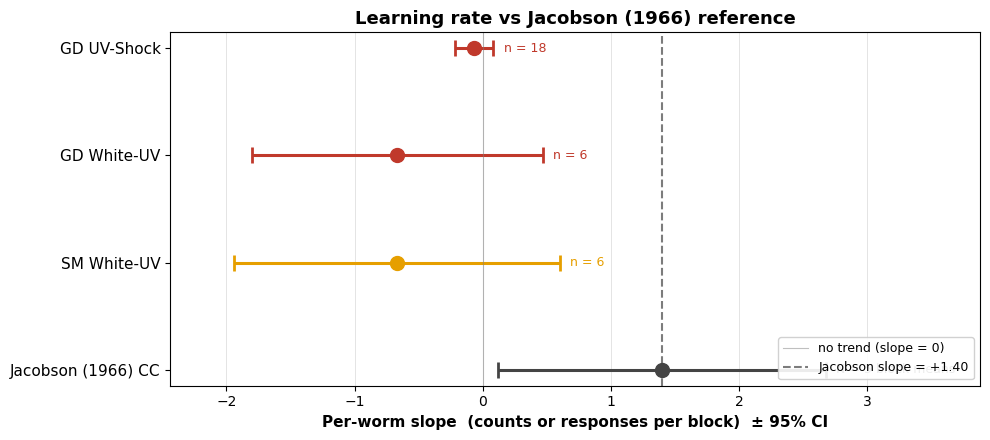


══════════════════════════════════════════════════════════════════════════════
  CAVEATS
══════════════════════════════════════════════════════════════════════════════
  • Jacobson published group MEANS only (N=5 conditioning blocks), not
    per-worm data. The Jacobson SE captures block-to-block fluctuation,
    NOT subject variance — so the true uncertainty on the Jacobson rate
    is probably LARGER than 0.402 resp/block. The Welch test therefore
    likely OVERSTATES the evidence for any rate difference.
  • Different species: Jacobson used Dugesia tigrina; we use Schmidtea
    mediterranea (SM) and Girardia dorotocephala (GD). This is a
    between-experiment comparison, not a replication.
  • Different CS: Jacobson used visible incandescent light; we use UV.
  • SM_WHITEUV has only 2 blocks → each per-worm 'slope' is a single
    Δ (B2 − B1) difference score, not a regression slope.
  • Trial counts per block match (25 / 25), so scoring SCALE is
    commensurate (responses/block

In [60]:
# ══════════════════════════════════════════════════════════════════════════════
#  Compare each population's learning rate to Jacobson (1966) CC reference
#  Depends on cell 9 (defines trend_gd_uv, trend_gd_wu, trend_sm_wu,
#  COLOR_UVSHOCK, COLOR_WHITEUV_GD, COLOR_WHITEUV_SM).
#
#  Approach
#  ────────
#  Jacobson published group MEANS only (N=5 conditioning blocks).
#  Linear regression on those 5 means gives:
#      slope = +1.400 ± 0.402 (SE) responses/block,  t(3) ≈ 3.48,  p ≈ 0.04
#  So the Jacobson "true" slope has non-trivial uncertainty of its own.
#
#  For each of our populations (GD UV-Shock, GD White-UV, SM White-UV) we have
#  per-worm slopes (from analyze_combined_paradigm in cell 9). We run two tests:
#    ① One-sample t-test  — Jacobson treated as fixed reference (lower bound on p)
#    ② Welch's t-test     — accounts for Jacobson's own SE (more honest)
#  Plus a forest plot showing each slope estimate with 95% CI against Jacobson.
#
#  Interpretation guide
#  ────────────────────
#    • If the CI on our population's slope EXCLUDES Jacobson's slope: we can
#      claim "did not learn at Jacobson's rate".
#    • If our CI INCLUDES Jacobson's slope: cannot distinguish — but absence
#      of evidence ≠ evidence of absence (would need TOST / BF for equivalence).
# ══════════════════════════════════════════════════════════════════════════════

# ── Jacobson reference slope from published block means ─────────────────────
JAC_CC_VALS   = np.array([9.2, 12.5, 11.1, 14.7, 15.1])   # CC1..CC5
JAC_CC_BLOCKS = np.array([1, 2, 3, 4, 5], dtype=float)
jac_reg       = stats.linregress(JAC_CC_BLOCKS, JAC_CC_VALS)
JAC_SLOPE     = jac_reg.slope
JAC_SLOPE_SE  = jac_reg.stderr
JAC_DF        = len(JAC_CC_BLOCKS) - 2     # 3

print("═" * 78)
print(f"  Jacobson (1966) CC reference slope  (N=5 published block means)")
print(f"    slope = {JAC_SLOPE:+.3f} responses/block")
print(f"    SE    = {JAC_SLOPE_SE:.3f}")
print(f"    t({JAC_DF}) = {JAC_SLOPE/JAC_SLOPE_SE:+.3f},  p = {jac_reg.pvalue:.4f}")
print("═" * 78)


def _slopes_from_trend(res):
    """Extract per-worm slope array from analyze_combined_paradigm() output."""
    if res is None or 'error' in res:
        return None
    return np.array(list(res['slope_test']['per_worm'].values()))


def compare_to_jacobson(name, slopes,
                        jac_slope=JAC_SLOPE, jac_se=JAC_SLOPE_SE, jac_df=JAC_DF):
    """Print one-sample t and Welch's t comparing `slopes` mean to Jacobson."""
    if slopes is None or len(slopes) < 2:
        print(f"\n  {name}: too few worms for inference")
        return None

    n         = len(slopes)
    mu        = slopes.mean()
    sd        = slopes.std(ddof=1)
    se        = sd / np.sqrt(n)
    df_pop    = n - 1
    tc_pop    = stats.t.ppf(0.975, df=df_pop)
    ci_pop    = (mu - tc_pop * se, mu + tc_pop * se)

    # ① One-sample t-test vs Jacobson (fixed reference)
    t1, p1_two = stats.ttest_1samp(slopes, jac_slope)
    p1_lower   = stats.t.cdf(t1, df=df_pop)          # H1: μ_pop < jac_slope
    d1         = (mu - jac_slope) / sd

    # ② Welch's t-test (accounts for Jacobson SE)
    diff      = mu - jac_slope
    se_diff   = np.sqrt(se ** 2 + jac_se ** 2)
    t2        = diff / se_diff
    df_w      = ((se ** 2 + jac_se ** 2) ** 2 /
                 ((se ** 2) ** 2 / df_pop + (jac_se ** 2) ** 2 / jac_df))
    p2_two    = 2 * stats.t.sf(abs(t2), df=df_w)
    p2_lower  = stats.t.cdf(t2, df=df_w)
    tc_w      = stats.t.ppf(0.975, df=df_w)
    ci_diff   = (diff - tc_w * se_diff, diff + tc_w * se_diff)

    pop_ci_excludes_jac = (ci_pop[1] < jac_slope) or (ci_pop[0] > jac_slope)

    print(f"\n  {'─' * 70}")
    print(f"  {name}   (n = {n} worms)")
    print(f"    Mean slope : {mu:+.3f} ± {se:.3f} SEM"
          f"   95% CI [{ci_pop[0]:+.3f}, {ci_pop[1]:+.3f}]")
    print(f"    Jacobson   : {jac_slope:+.3f} ± {jac_se:.3f} SE (N=5 block means)")
    print(f"    Difference : {diff:+.3f}")
    print(f"    ① One-sample t  (Jacobson as fixed reference)")
    print(f"         t({df_pop}) = {t1:+.3f},  p(two-sided) = {p1_two:.4f},  "
          f"p(slope < Jac) = {p1_lower:.4f}")
    print(f"         Cohen's d = {d1:+.3f}")
    print(f"         95% CI excludes Jacobson? {pop_ci_excludes_jac}")
    print(f"    ② Welch's t   (accounts for Jacobson SE)")
    print(f"         t({df_w:.1f}) = {t2:+.3f},  p(two-sided) = {p2_two:.4f},  "
          f"p(slope < Jac) = {p2_lower:.4f}")
    print(f"         95% CI on (slope − Jacobson): [{ci_diff[0]:+.3f}, {ci_diff[1]:+.3f}]")
    print(f"         CI includes 0? {ci_diff[0] <= 0 <= ci_diff[1]}")
    print(f"    ▶ Verdict:")
    if p2_two < 0.05 and mu < jac_slope:
        print(f"         Slope significantly LOWER than Jacobson (Welch p = {p2_two:.4f})")
    elif p2_two < 0.05 and mu > jac_slope:
        print(f"         Slope significantly HIGHER than Jacobson (Welch p = {p2_two:.4f})")
    else:
        print(f"         Cannot distinguish from Jacobson (Welch p = {p2_two:.4f})")
        print(f"         (absence of significance ≠ equivalence; use TOST/BF for that)")

    return dict(
        name=name, n=n, mu=mu, se=se, sd=sd, ci=ci_pop,
        diff=diff, p1_two=p1_two, p1_lower=p1_lower, d=d1,
        t_welch=t2, df_welch=df_w, p_welch_two=p2_two, p_welch_lower=p2_lower,
        ci_diff=ci_diff, ci_excludes_jac=pop_ci_excludes_jac,
    )


# ── Pull per-worm slopes from cell 9's trend results ────────────────────────
slopes_gd_uv = _slopes_from_trend(trend_gd_uv)
slopes_gd_wu = _slopes_from_trend(trend_gd_wu)
slopes_sm_wu = _slopes_from_trend(trend_sm_wu)

print("\n" + "═" * 78)
print(f"  COMPARISON TO JACOBSON CC  (reference slope = {JAC_SLOPE:+.3f} resp/block)")
print("═" * 78)

cmp_gd_uv = compare_to_jacobson('GD UV-Shock',  slopes_gd_uv)
cmp_gd_wu = compare_to_jacobson('GD White-UV',  slopes_gd_wu)
cmp_sm_wu = compare_to_jacobson('SM White-UV',  slopes_sm_wu)

# ── Forest plot: slopes ± 95% CI side-by-side with Jacobson ─────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

entries = []   # (label, mean, lo, hi, color, n_str)

def _add(label, slopes, color):
    if slopes is None or len(slopes) < 2:
        return
    mu  = slopes.mean()
    se  = slopes.std(ddof=1) / np.sqrt(len(slopes))
    tc  = stats.t.ppf(0.975, df=len(slopes) - 1)
    entries.append((label, mu, mu - tc * se, mu + tc * se, color,
                    f"n = {len(slopes)}"))

_add('GD UV-Shock', slopes_gd_uv, COLOR_UVSHOCK)
_add('GD White-UV', slopes_gd_wu, COLOR_WHITEUV_GD)
_add('SM White-UV', slopes_sm_wu, COLOR_WHITEUV_SM)
# Jacobson reference
jac_tc = stats.t.ppf(0.975, df=JAC_DF)
entries.append(('Jacobson (1966) CC',
                JAC_SLOPE,
                JAC_SLOPE - jac_tc * JAC_SLOPE_SE,
                JAC_SLOPE + jac_tc * JAC_SLOPE_SE,
                '#444444',
                'N = 5 block means'))

ypos = list(range(len(entries), 0, -1))
for y, (label, mu, lo, hi, color, n_str) in zip(ypos, entries):
    ax.errorbar(mu, y, xerr=[[mu - lo], [hi - mu]],
                fmt='o', color=color, markersize=10,
                capsize=6, capthick=2, linewidth=2.2)
    ax.text(hi + 0.08, y, n_str, va='center', ha='left',
            fontsize=9, color=color)

ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5,
           label='no trend (slope = 0)')
ax.axvline(JAC_SLOPE, color='#444444', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Jacobson slope = {JAC_SLOPE:+.2f}')

ax.set_yticks(ypos)
ax.set_yticklabels([e[0] for e in entries], fontsize=11)
ax.set_xlabel('Per-worm slope  (counts or responses per block)  ± 95% CI',
              fontsize=11, fontweight='bold')
ax.set_title('Learning rate vs Jacobson (1966) reference',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, axis='x', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Pad x-axis to leave room for n-labels at the right
xmin = min(e[2] for e in entries) - 0.5
xmax = max(e[3] for e in entries) + 1.2
ax.set_xlim(xmin, xmax)

plt.tight_layout()
savepath = '../figures/Fig2A_SlopeVsJacobson.svg'
fig.savefig(savepath, dpi=300, bbox_inches='tight')
print(f"\nSaved: {savepath}")
plt.show()

# ── Caveats summary ─────────────────────────────────────────────────────────
print("\n" + "═" * 78)
print("  CAVEATS")
print("═" * 78)
print("  • Jacobson published group MEANS only (N=5 conditioning blocks), not")
print("    per-worm data. The Jacobson SE captures block-to-block fluctuation,")
print("    NOT subject variance — so the true uncertainty on the Jacobson rate")
print("    is probably LARGER than 0.402 resp/block. The Welch test therefore")
print("    likely OVERSTATES the evidence for any rate difference.")
print("  • Different species: Jacobson used Dugesia tigrina; we use Schmidtea")
print("    mediterranea (SM) and Girardia dorotocephala (GD). This is a")
print("    between-experiment comparison, not a replication.")
print("  • Different CS: Jacobson used visible incandescent light; we use UV.")
print("  • SM_WHITEUV has only 2 blocks → each per-worm 'slope' is a single")
print("    Δ (B2 − B1) difference score, not a regression slope.")
print("  • Trial counts per block match (25 / 25), so scoring SCALE is")
print("    commensurate (responses/block vs contractions/block).")
print("  • Defensible claim: 'population X did not acquire at Jacobson's rate'")
print("    when CI excludes +1.40.  Indefensible: 'X cannot be conditioned'.")
print("═" * 78)


In [61]:
# Plot 2: Pulse-UV only — W6 excluded
# ─────────────────────────────────────────────────────────────────────────────
# W6 in SM_PULSEUV only contributed data for block 3 (a sixth worm was briefly
# recovered after one had escaped, then escaped again before block 4). The
# other 5 lanes (W1–W5) span blocks 1–4 consistently. We drop W6 here so that
# every block has the same set of 5 worms.
#
# NOTE on the trend-test results: the per-worm slopes are UNCHANGED by this
# exclusion (W6 had only one block of data, so it never contributed a slope
# to begin with). What does change is block 3's pooled mean / SEM, because W6
# previously contributed a value of 0 to that block's mean.
# ─────────────────────────────────────────────────────────────────────────────
df_pulse = df.copy()
df_pulse.loc[df_pulse['Troupe'] == 'SM_PULSEUV', 'W6'] = np.nan

# Override the label on the Pulse-UV paradigm dict to reflect the n=5 sample
PARADIGM_GROUPS_PULSE_N5 = {
    k: {**v, 'label': 'Pulse-UV  (n=5; W6 excluded)'}
    for k, v in PARADIGM_GROUPS_PULSE.items()
}

pulse_stats = create_paradigm_graph(
    df_pulse,
    paradigm_groups_dict = PARADIGM_GROUPS_PULSE_N5,
    error_type  = 'SEM',
    y_values    = 'counts',
    ylim        = 22,
    title       = 'Pulse-UV paradigm analysis  (n=5, W6 excluded)',
    ylabel      = 'Mean number of contractions',
    x_offset    = 0.0,
    sesoi       = 1.0,
    run_trend_test = True,
    show_individual_worms = True,
    save        = True,
    filename    = '../figures/Fig2B_PulseUV.svg',
)

Pulse-UV Block 1: Mean=5.000, SEM=3.271, N=5 worms
Pulse-UV Block 2: Mean=4.800, SEM=3.089, N=5 worms
Pulse-UV Block 3: Mean=10.000, SEM=3.564, N=5 worms
Pulse-UV Block 4: Mean=4.800, SEM=3.200, N=5 worms

══════════════════════════════════════════════════════════════════════════
  PARADIGM-LEVEL TREND ANALYSIS  ─  Pulse-UV paradigm analysis  (n=5, W6 excluded)
  Worms pooled across troupes within each paradigm
  H₁: upward trend (slope > 0)  |  α = 0.05  |  SESOI = ±1.0 cts/block
══════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────────
  PARADIGM : Pulse-UV
  Troupes  : SM_PULSEUV
  Blocks   : [1, 2, 3, 4]
  N worms with ≥ 2 blocks of data : 5

  ① Per-worm slope t-test  (n = 5 slopes pooled)
     Mean slope : +0.460 ± 0.201 SEM
     95 % CI    : [-0.099,  +1.019]
     t(4) = +2.283,  p (two-sided) = 0.0845,  p (one-sided ↑) = 0.0423
     Per worm : W1(SM_PULSEUV)=+0.10  W2(SM_PULSEUV)=+1.20 


══════════════════════════════════════════════════════════════════════════════
  PULSE-UV vs JACOBSON CC  (reference slope = +1.400 resp/block)
══════════════════════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────────────────
  Pulse-UV (SM, W6 excluded)   (n = 5 worms)
    Mean slope : +0.460 ± 0.201 SEM   95% CI [-0.099, +1.019]
    Jacobson   : +1.400 ± 0.402 SE (N=5 block means)
    Difference : -0.940
    ① One-sample t  (Jacobson as fixed reference)
         t(4) = -4.665,  p(two-sided) = 0.0096,  p(slope < Jac) = 0.0048
         Cohen's d = -2.086
         95% CI excludes Jacobson? True
    ② Welch's t   (accounts for Jacobson SE)
         t(4.5) = -2.090,  p(two-sided) = 0.0973,  p(slope < Jac) = 0.0486
         95% CI on (slope − Jacobson): [-2.137, +0.257]
         CI includes 0? True
    ▶ Verdict:
         Cannot distinguish from Jacobson (Welch p = 0.0973)
         (absence of significance ≠ equivalenc

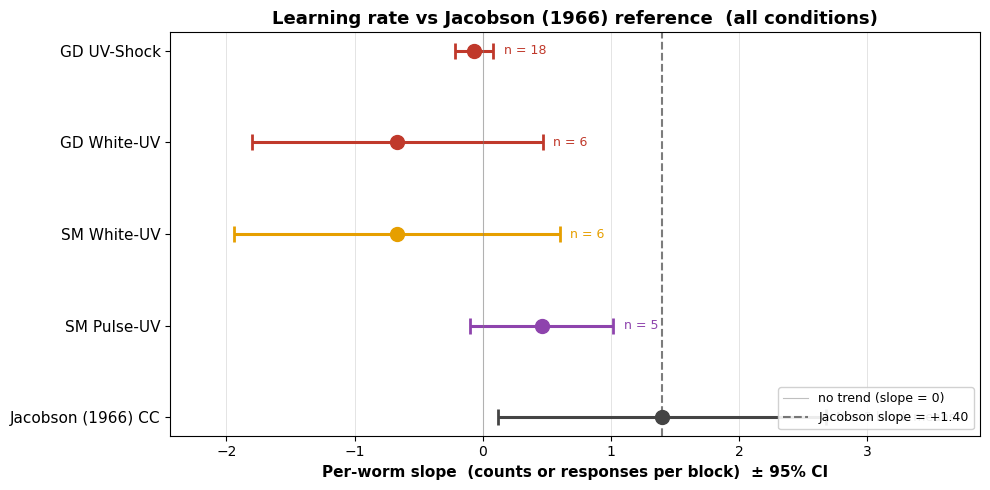

In [62]:
# ══════════════════════════════════════════════════════════════════════════════
#  Compare Pulse-UV learning rate against Jacobson (1966) CC reference
#  ────────────────────────────────────────────────────────────────────────────
#  Depends on:
#    • cell 10 — JAC_SLOPE, JAC_SLOPE_SE, JAC_DF, compare_to_jacobson(),
#                _slopes_from_trend(), slopes_gd_uv / slopes_gd_wu / slopes_sm_wu
#    • cell 11 — pulse_stats  (Pulse-UV trend test, W6 excluded, n=5)
#
#  Pulse-UV was held out of cell 10's comparison because its dataframe is
#  filtered separately (W6 dropped). It is the only condition in the study
#  with a positive mean slope (+0.46 ± 0.20 SEM contractions/block). Below we
#  test whether that slope is also COMPARABLE to Jacobson's reported CC slope
#  (+1.40 ± 0.40 responses/block), and regenerate the forest plot with all
#  four populations side-by-side against Jacobson.
# ══════════════════════════════════════════════════════════════════════════════

# Extract Pulse-UV per-worm slopes (computed in cell 11 with W6 excluded)
trend_pulse  = pulse_stats['_trend_analysis']['Pulse-UV']
slopes_pulse = _slopes_from_trend(trend_pulse)

print("\n" + "═" * 78)
print(f"  PULSE-UV vs JACOBSON CC  (reference slope = {JAC_SLOPE:+.3f} resp/block)")
print("═" * 78)

cmp_pulse = compare_to_jacobson('Pulse-UV (SM, W6 excluded)', slopes_pulse)

# ── Forest plot: all 4 populations vs Jacobson ──────────────────────────────
COLOR_PULSEUV = '#8E44AD'   # purple — matches PARADIGM_GROUPS['Pulse-UV']['color']

fig, ax = plt.subplots(figsize=(10, 5))

entries_all = []   # (label, mean, lo, hi, color, n_str)

def _add4(label, slopes, color):
    if slopes is None or len(slopes) < 2:
        return
    mu  = slopes.mean()
    se  = slopes.std(ddof=1) / np.sqrt(len(slopes))
    tc  = stats.t.ppf(0.975, df=len(slopes) - 1)
    entries_all.append((label, mu, mu - tc * se, mu + tc * se, color,
                        f"n = {len(slopes)}"))

_add4('GD UV-Shock',  slopes_gd_uv,  COLOR_UVSHOCK)
_add4('GD White-UV',  slopes_gd_wu,  COLOR_WHITEUV_GD)
_add4('SM White-UV',  slopes_sm_wu,  COLOR_WHITEUV_SM)
_add4('SM Pulse-UV',  slopes_pulse,  COLOR_PULSEUV)
# Jacobson reference
jac_tc = stats.t.ppf(0.975, df=JAC_DF)
entries_all.append(('Jacobson (1966) CC',
                    JAC_SLOPE,
                    JAC_SLOPE - jac_tc * JAC_SLOPE_SE,
                    JAC_SLOPE + jac_tc * JAC_SLOPE_SE,
                    '#444444',
                    'N = 5 block means'))

ypos = list(range(len(entries_all), 0, -1))
for y, (label, mu, lo, hi, color, n_str) in zip(ypos, entries_all):
    ax.errorbar(mu, y, xerr=[[mu - lo], [hi - mu]],
                fmt='o', color=color, markersize=10,
                capsize=6, capthick=2, linewidth=2.2)
    ax.text(hi + 0.08, y, n_str, va='center', ha='left',
            fontsize=9, color=color)

ax.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5,
           label='no trend (slope = 0)')
ax.axvline(JAC_SLOPE, color='#444444', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Jacobson slope = {JAC_SLOPE:+.2f}')

ax.set_yticks(ypos)
ax.set_yticklabels([e[0] for e in entries_all], fontsize=11)
ax.set_xlabel('Per-worm slope  (counts or responses per block)  ± 95% CI',
              fontsize=11, fontweight='bold')
ax.set_title('Learning rate vs Jacobson (1966) reference  (all conditions)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, axis='x', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Pad x-axis to leave room for n-labels at the right
xmin = min(e[2] for e in entries_all) - 0.5
xmax = max(e[3] for e in entries_all) + 1.2
ax.set_xlim(xmin, xmax)

plt.tight_layout()
savepath = '../figures/Fig2_SlopeVsJacobson_AllConditions.svg'
fig.savefig(savepath, dpi=300, bbox_inches='tight')
print(f"\nSaved: {savepath}")
plt.show()
